In [8]:
%pip uninstall -y cyclical-fractional-test
%pip install --no-cache-dir --force-reinstall -e .

Found existing installation: cyclical-fractional-test 0.1.0
Uninstalling cyclical-fractional-test-0.1.0:
  Successfully uninstalled cyclical-fractional-test-0.1.0
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/asierlanda/Desktop/master/TFM/log_memory_cycles
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 16.7 MB/s  0:00:00 eta 0:00:01
  Building editable for cyclical-fractional-test (pyproject.toml) ... done
  Created wheel for cyclical-fractional-test: filename=cyclical_fractional_test-0.1.0-0.editable-py3-none-any.whl size=4466 sha256=9a5e4a6a47c9c52086415a45b8cc4dc4651e3509457bd937c315fb698cc9b646
  Stored in directory: /private/var/folders/04/st_535kd1r53zz13xp15rv9w0000gn/T/pip-ephem-wheel-cache-4_wnbmys/wheels/94/07/1e/db9b8b1

In [2]:
import numpy as np
from cyclical_fractional_test import CyclicalTestConfig, run_cyclical_fractional_test, compute_periodogram
from datetime import timezone
import time

import pandas as pd
from pathlib import Path
import requests
import matplotlib.pyplot as plt

In [15]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s",
    force=True,  # importante en notebooks
)

In [3]:
# Variables de entrada
A = "2021-01-01 00:00:00"
B = "2025-01-01 00:00:00"
INTERVAL = "1d"

# Ajusta el simbolo al instrumento exacto disponible en Binance.
# Ojo: Binance Spot no ofrece el indice S&P 500 cash como tal; si el simbolo no existe,
# la API devolvera "Invalid symbol". En futures, cambia MARKET a "um_futures" si aplica.
SYMBOL = "BTCUSDT"
MARKET = "spot"  # "spot" o "um_futures"

LIMIT = 1000
REQUEST_PAUSE_SECONDS = 0.2

ENDPOINTS = {
    "spot": "https://api.binance.com/api/v3/klines",
    "um_futures": "https://fapi.binance.com/fapi/v1/klines",
}

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok= True)

In [ ]:
def to_milliseconds(value: str) -> int:
    timestamp = pd.Timestamp(value)
    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize(timezone.utc)
    else:
        timestamp = timestamp.tz_convert(timezone.utc)
    return int(timestamp.timestamp() * 1000)


def interval_to_milliseconds(interval: str) -> int:
    units = {
        "m": 60_000,
        "h": 60 * 60_000,
        "d": 24 * 60 * 60_000,
        "w": 7 * 24 * 60 * 60_000,
    }
    unit = interval[-1]
    if unit not in units:
        raise ValueError(f"Intervalo no soportado por esta funcion: {interval!r}")
    return int(interval[:-1]) * units[unit]


def fetch_binance_klines(symbol: str, start: str, end: str, interval: str = "1h", market: str = "spot") -> pd.DataFrame:
    if market not in ENDPOINTS:
        raise ValueError(f"MARKET debe ser uno de {list(ENDPOINTS)}")

    endpoint = ENDPOINTS[market]
    start_ms = to_milliseconds(start)
    end_ms = to_milliseconds(end)
    step_ms = interval_to_milliseconds(interval)
    rows = []

    while start_ms < end_ms:
        params = {
            "symbol": symbol.upper(),
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": LIMIT,
        }
        response = requests.get(endpoint, params=params, timeout=30)
        response.raise_for_status()
        batch = response.json()

        if isinstance(batch, dict):
            raise RuntimeError(f"Error de Binance: {batch}")
        if not batch:
            break

        rows.extend(batch)
        last_open_time = batch[-1][0]
        next_start_ms = last_open_time + step_ms
        if next_start_ms <= start_ms:
            break
        start_ms = next_start_ms

        if len(batch) == LIMIT:
            time.sleep(REQUEST_PAUSE_SECONDS)

    columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
        "ignore",
    ]
    df = pd.DataFrame(rows, columns=columns)
    if df.empty:
        return df

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
    ]
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
    df["number_of_trades"] = pd.to_numeric(df["number_of_trades"], errors="coerce").astype("Int64")

    end_timestamp = pd.Timestamp(end)
    if end_timestamp.tzinfo is None:
        end_timestamp = end_timestamp.tz_localize(timezone.utc)
    else:
        end_timestamp = end_timestamp.tz_convert(timezone.utc)

    return df.loc[df["open_time"] < end_timestamp].reset_index(drop=True)


bitcoin_prices = fetch_binance_klines(SYMBOL, A, B, INTERVAL, MARKET)
bitcoin_prices[['open_time', 'open']].to_csv(DATA_DIR / 'btc_prices_1d.csv', index = False)

In [1]:
import sys
import logging
import importlib
import pandas as pd
from pathlib import Path
import numpy as np

# 1. Asegura que Python mira al repo local
repo_root = Path("/Users/asierlanda/Desktop/master/TFM/log_memory_cycles")
src_path = repo_root / "src"

if str(src_path) in sys.path:
    sys.path.remove(str(src_path))
sys.path.insert(0, str(src_path))

# 2. Fuerza recarga del módulo local
import cyclical_fractional_test.api as api
api = importlib.reload(api)

print(api.__file__)  # debe apuntar a src/cyclical_fractional_test/api.py

# 3. Configura logger DIRECTAMENTE sobre ese módulo
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)
handler.setFormatter(logging.Formatter("%(levelname)s:%(name)s:%(message)s"))

api.logger.handlers.clear()
api.logger.addHandler(handler)
api.logger.setLevel(logging.INFO)
api.logger.propagate = False


DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok= True)

df = pd.read_csv(DATA_DIR / 'btc_prices_1d.csv')
y = df['open']

/Users/asierlanda/Desktop/master/TFM/log_memory_cycles/src/cyclical_fractional_test/api.py


In [5]:
api.logger.setLevel(logging.WARNING)
# api.logger.setLevel(logging.INFO)
y_fist_differences = np.zeros(len(y)-1)
for i in range(len(y) - 1):
    y_fist_differences[i] = y[i + 1] - y[i]


test_config = api.CyclicalTestConfig(
    n_deterministic_cycles= 3,
    include_intercept= False,
    d_grid= np.linspace(0.0, 1.0, 101),
    r_window= 10,
    top_k= 5,
    statistic_mode= 'test',
    stochastic_cycle_mode= 'single',
    exclude_zero_frequency= True
)

result = api.run_cyclical_fractional_test(y, config= test_config)

best = result.best_result
cycle = best.cycles[0]

print('best R:',cycle.R,'best D:', cycle.D)
print('betas:', best.betas)

print('test_value:', best.test_value)
print(best.test_star_value)
print('best xa:', best.xa,'best xaa:', best.xaa)
print(best.variance_time, best.variance_frequency)

best R: 2 best D: 0.54
betas: [-2667.98750174 15331.17449533  1586.61373069]
test_value: 0.027586251011489867
0.027592447694527997
best xa: 3996.0618208648843 best xaa: 6.171421030420868
2228804.8012929927 2228304.2586423233


lambda: 0 I: 421408584653.8621 len: 1461


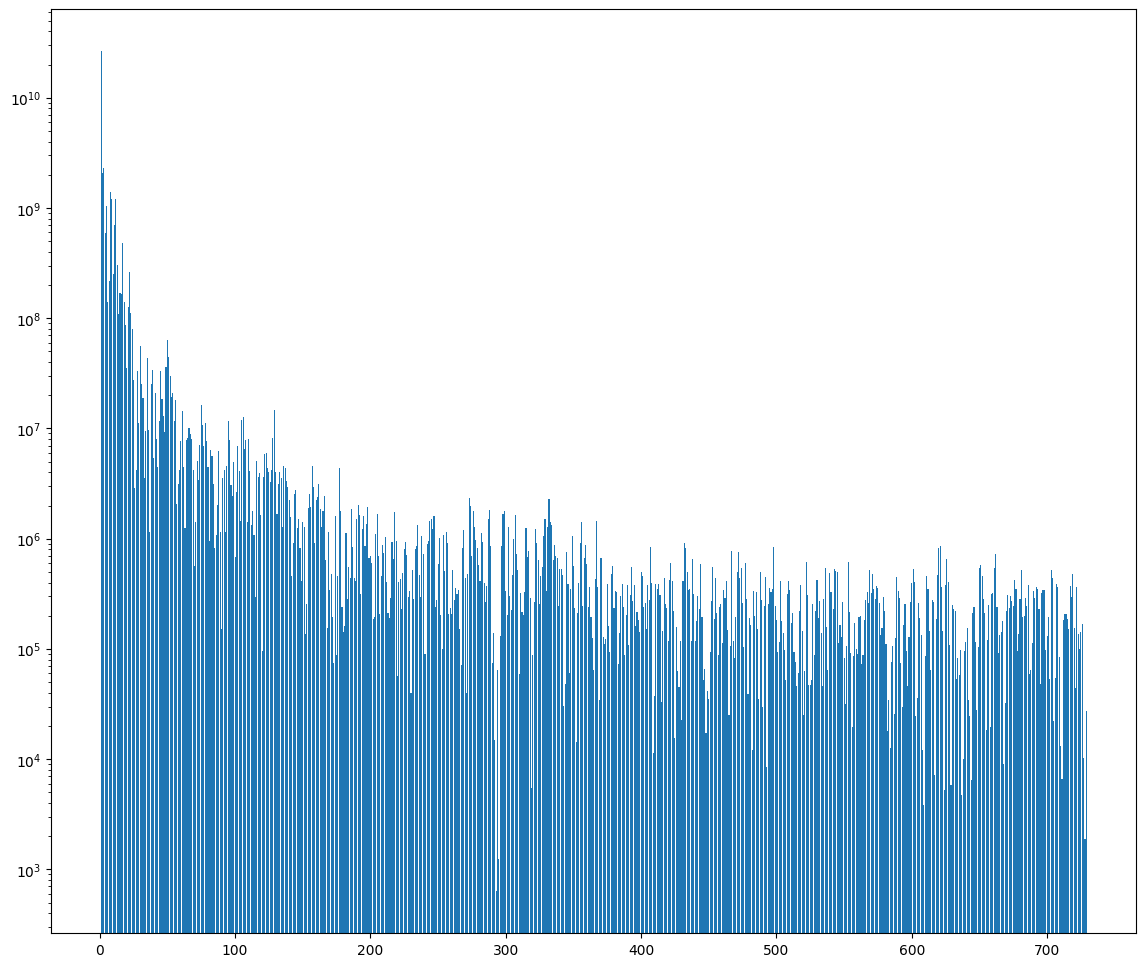

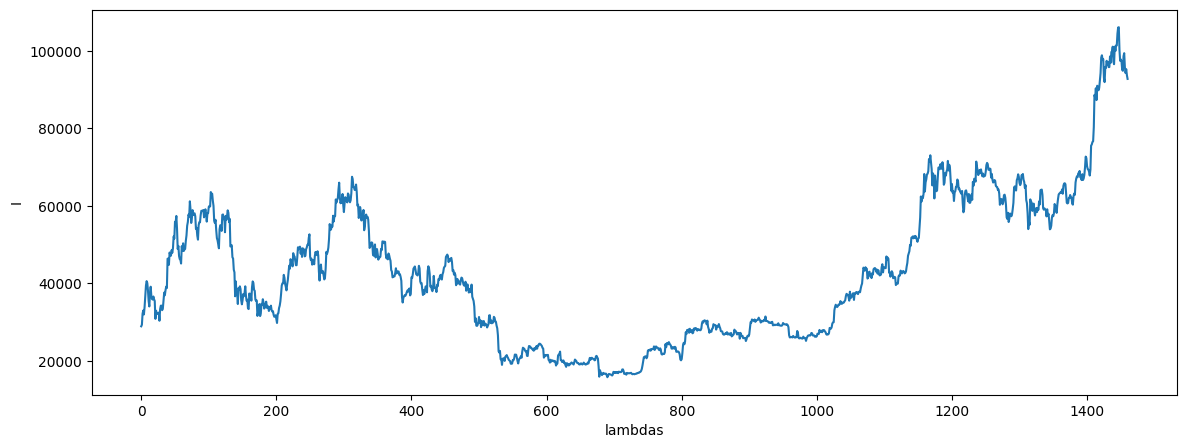

In [15]:
import matplotlib.pyplot as plt

lambdas, I = api.compute_periodogram(y)

jey = range(len(lambdas))

higest = 0
for i in range(len(I)):
    if I[i] > higest:
        higest = I[i]
        j = i
print('lambda:', jey[j], 'I:', I[j], 'len:', len(I))


min_range = 1
max_range = len(I)//2

# print(lambdas, I)
plt.figure(figsize= [14, 12])
plt.bar(jey[min_range:max_range], I[min_range:max_range])
plt.yscale('log')
# Çprint(I[min_range: max_range].max(), I[min_range: max_range].argmax() + min_range)
plt.figure(figsize=[14,5])
plt.plot(y)
# plt.hist(I, bins = 50)
plt.xlabel('lambdas')
plt.ylabel('I')
plt.show()